In [31]:
import numpy as np
from scipy.special import expit, erf
from numpy.linalg import solve, cholesky
import matplotlib.pyplot as plt

# Chatgpt code to verify that CAVI and Gibbs do the same thing

In [ ]:
import numpy as np
from scipy.special import expit
from numpy.linalg import inv, solve, cholesky

# ------------------------------------------------------------------
#                   1.  Synthetic data
# ------------------------------------------------------------------
n, m = 2_000, 20
X      = np.random.randn(n, 1)
freqs  = np.linspace(-10, 10, m)[:, None]
# Phi    = np.sqrt(2 / m) * np.cos(X @ freqs.T) 
Phi = np.random.randn(n,m)

beta_true =  np.random.randn(m)
f_true    = Phi @ beta_true
y         = np.random.binomial(1, expit(f_true))
# ------------------------------------------------------------------
#                   2.  Polya–Gamma utilities
# ------------------------------------------------------------------
def pgdraw_vec(c, K=100):
    """Draw ω ~ PG(1,c) via truncated infinite sum (Polson‑Scott‑Windle)."""
    c   = np.abs(c)
    k   = np.arange(1, K + 1)[:, None]      # shape (K,1)
    term= (k - 0.5)**2 + (c / (2*np.pi))**2
    g   = np.random.gamma(shape=1.0, scale=1.0, size=(K, c.size))
    return (g/term).sum(axis=0) / (2*np.pi**2)

def pg_expect(c):
    """E[ω|c] for ω~PG(1,c).  Vectorised and numerically stable at c≈0."""
    out          = np.empty_like(c)
    safe         = c > 1e-8
    out[safe]    = 0.5 * np.tanh(c[safe]/2) / c[safe]
    out[~safe]   = 0.25          # limit as c→0
    return out

# ------------------------------------------------------------------
#                   3.  CAVI
# ------------------------------------------------------------------
def cavi(Phi, y, max_iter=50, tol=1e-6):
    n, m = Phi.shape
    d = np.full(n, 0.25)                       # E[ω] initial
    for _ in range(max_iter):
        precision = (Phi.T * d) @ Phi + np.eye(m)
        Sigma     = inv(precision)
        mu        = Sigma @ (Phi.T @ (y - 0.5))

        s_phi     = np.sum(Phi * (Phi @ Sigma), axis=1)
        c         = np.sqrt(s_phi + (Phi @ mu)**2)
        d_new     = pg_expect(c)

        if np.linalg.norm(d_new - d) < tol:
            d = d_new
            break
        d = d_new
    return mu, Sigma

# ------------------------------------------------------------------
#                   4.  Gibbs sampler  (fixed)
# ------------------------------------------------------------------
def gibbs_pg(Phi, y, n_iter=1200, burn=400, K=100):
    """
    Returns posterior mean and covariance of β via PG‑Gibbs.
    Uses one triangular solve per draw for efficiency.
    """
    n, m = Phi.shape
    beta = np.zeros(m)
    keep = []

    for it in range(n_iter):
        # ---- ω | β ----
        omega = pgdraw_vec(Phi @ beta, K=K)

        # ---- β | ω ----
        precision = (Phi.T * omega) @ Phi + np.eye(m)
        L         = cholesky(precision)                   # precision = L Lᵀ
        rhs       = Phi.T @ (y - 0.5)

        # conditional mean μ = precision^{-1} rhs  via two triangular solves
        mu = solve(L.T, solve(L, rhs))

        # sample β = μ + precision^{-1/2} z
        z     = np.random.randn(m)
        beta  = mu + solve(L, z)                # one solve gives L^{-1} z

        if it >= burn:
            keep.append(beta.copy())

    samples = np.stack(keep)
    beta_mean = samples.mean(axis=0)
    centered  = samples - beta_mean
    beta_cov  = centered.T @ centered / (samples.shape[0] - 1)
    return beta_mean, beta_cov

# ------------------------------------------------------------------
#                   5.  Natural‑gradient SVI
# ------------------------------------------------------------------
def natural_grad(Phi, y, s=200, rho=0.05, iters=300):
    n, m = Phi.shape
    eta1 = np.zeros(m)          # Σ^{-1} μ
    d    = np.full(n, 0.25)     # θ_i = E[ω_i]

    for _ in range(iters):
        precision = (Phi.T * d) @ Phi + np.eye(m)
        Sigma     = inv(precision)
        mu        = solve(precision, eta1)

        S        = np.random.choice(n, size=s, replace=False)
        Phi_S    = Phi[S]
        c_S      = np.sqrt(np.sum(Phi_S * (Phi_S @ Sigma), axis=1)
                           + (Phi_S @ mu)**2)
        theta_S  = pg_expect(c_S)

        eta1 = (1 - rho) * eta1 + rho * (n / s) * (Phi_S.T @ (y[S] - 0.5))
        d    = (1 - rho) * d
        d[S] += rho * (n / s) * theta_S

    precision = (Phi.T * d) @ Phi + np.eye(m)
    Sigma     = inv(precision)
    mu        = solve(precision, eta1)
    return mu, Sigma

# ------------------------------------------------------------------
#                   6.  Run & compare
# ------------------------------------------------------------------
mu_vi,  Sigma_vi  = cavi(Phi, y)
mu_ng,  Sigma_ng  = natural_grad(Phi, y)
mu_gs,  Sigma_gs  = gibbs_pg(Phi, y)

def evaluate(beta_est):
    f_est = Phi @ beta_est
    acc   = np.mean((f_est > 0) == y)
    err   = np.linalg.norm(beta_est - beta_true)
    return acc, err

print("---------------  Performance  ---------------")
for name, beta_hat in zip(["CAVI", "Nat‑grad", "Gibbs"],
                          [mu_vi,  mu_ng,    mu_gs]):
    acc, err = evaluate(beta_hat)
    print(f"{name:8s}  acc = {acc*100:5.1f}%   L2‑err = {err:6.2f}")


---------------  Performance  ---------------
CAVI      acc =  88.8%   L2‑err =   0.32
Nat‑grad  acc =  88.6%   L2‑err =   0.30
Gibbs     acc =  88.6%   L2‑err =   0.35


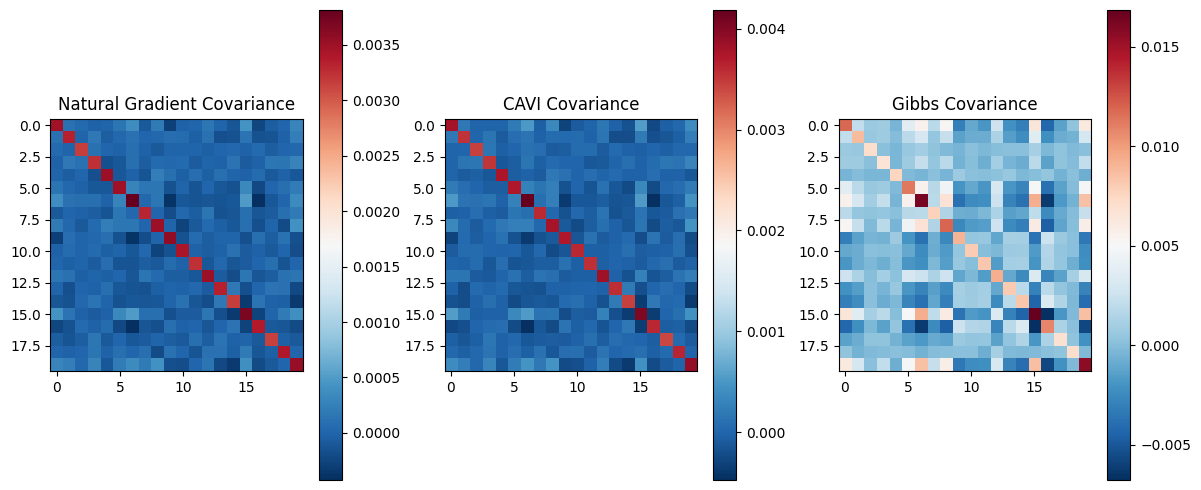

In [33]:
import matplotlib.pyplot as plt

# Create a figure with three subplots side by side
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))

# Plot Sigma_ng
im1 = ax1.imshow(Sigma_ng, cmap='RdBu_r')
ax1.set_title('Natural Gradient Covariance')
plt.colorbar(im1, ax=ax1)

# Plot Sigma_cavi 
im2 = ax2.imshow(Sigma_vi, cmap='RdBu_r')
ax2.set_title('CAVI Covariance')
plt.colorbar(im2, ax=ax2)

# Plot Sigma_gibbs
im3 = ax3.imshow(Sigma_gs, cmap='RdBu_r')
ax3.set_title('Gibbs Covariance')
plt.colorbar(im3, ax=ax3)

plt.tight_layout()
plt.show()
